In [27]:
import seaborn as sns
import matplotlib.pyplot as plt 
import warnings
import numpy as np
import pandas as pd 
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from joblib import Parallel,delayed
from tqdm.notebook import tqdm
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV,LeaveOneOut
from fbsc_class import FBSC

In [2]:
# D = pd.read_csv("../data/streamlit_sample_data.csv").set_index('name').drop(columns=['position','height','mz'])
# D = D.loc[:,D.columns.str.contains(".mzML area")]
# D.columns = D.columns.str.replace(".mzML area","")
# D = D.replace(0,np.nan)
# min_val = D.min().min() * .10
# D = D.T
# M = pd.read_csv("../data/streamlit_sample_metadata.csv")
# M = M.set_index("sample_name")
# M['batch'] = M['batch'].str.split("_",expand=True)[1].astype(int)
# M = M[M['batch'] <= 13]
# D = D.loc[M.index]
# M = M.sort_values(by=['batch','injection_order'])
# M['injection_order'] = [x for x in range(len(M.injection_order))]

D = pd.read_csv("../data/streamlit_sample_data.csv")
M = pd.read_csv("../data/streamlit_sample_metadata.csv")
M = M[M['batch'] <= 2]
D = D.loc[M.index,:]



# FBSC Class

In [3]:
test = FBSC(data=D,metadata=M,method="QC-SVRC")

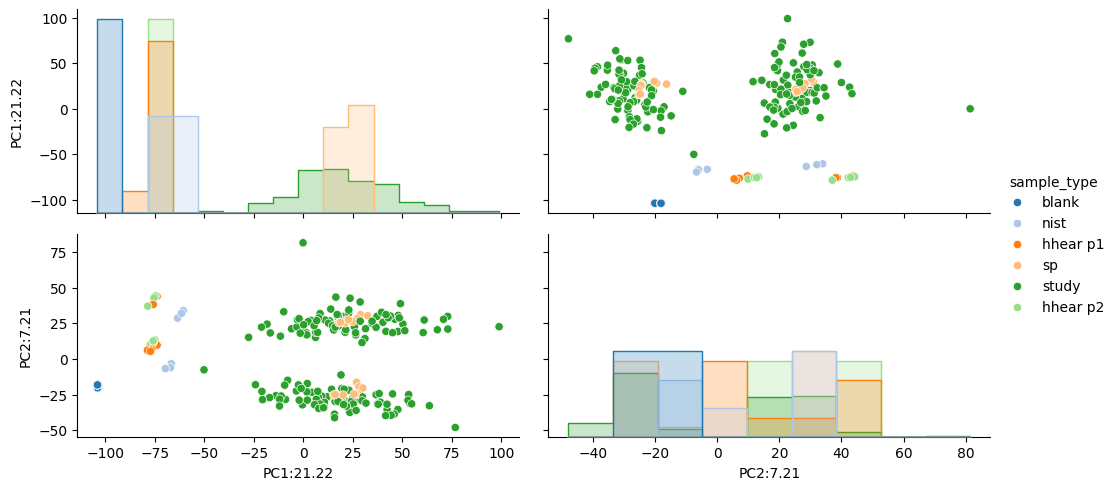

plotting only QC and Biological Samples


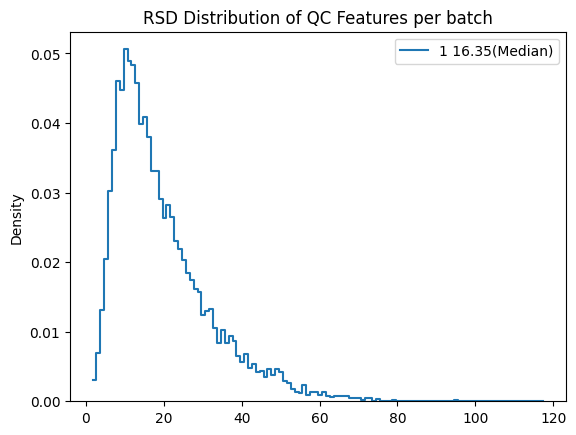

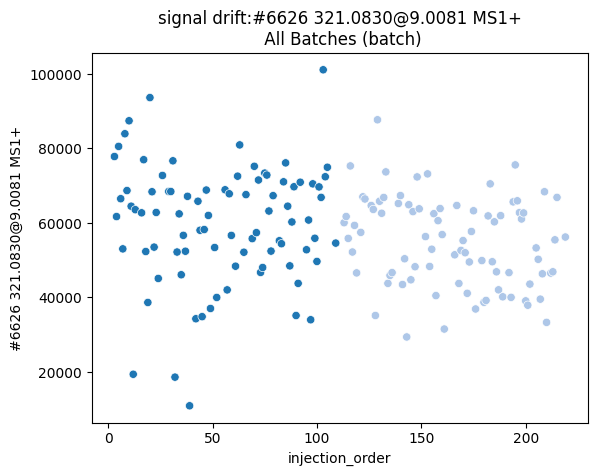

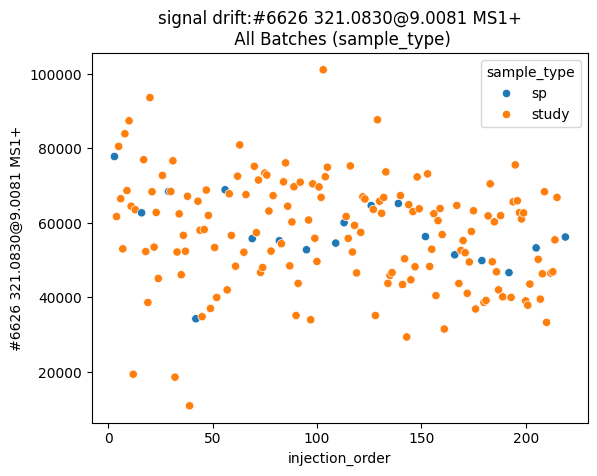

In [4]:
test.pca_pairplot(n_components=2,hue='sample_type')
test.rsd_distribution(batch=[1])
plt.figure()
test.plot_signal_drift(include_all_batches=True,include_all_samples=False)

In [6]:
df = test.fbsc_correction()

Correcting signals...:   0%|          | 0/10781 [00:00<?, ?it/s]

Correcting signals...:   0%|          | 0/10781 [00:00<?, ?it/s]